# Esplorazione del dataset Flickr8k

Obiettivo: capire cosa c'è dentro al dataset prima di costruire il modello.

- 8091 immagini (Flickr, varie scene quotidiane)
- 5 didascalie per immagine, scritte da annotatori umani diversi
- Totale: ~40455 coppie (immagine, didascalia)

In [ ]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image

# Path "robusti" che funzionano da qualsiasi cella
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data" / "flickr8k"
IMAGES_DIR = DATA_DIR / "Images"
CAPTIONS_FILE = DATA_DIR / "captions.txt"

print(f"Project root: {PROJECT_ROOT}")
print(f"Images dir esiste: {IMAGES_DIR.exists()}")
print(f"Captions file esiste: {CAPTIONS_FILE.exists()}")

In [ ]:
df = pd.read_csv(CAPTIONS_FILE)
print(f"Righe totali: {len(df)}")
print(f"Immagini uniche: {df['image'].nunique()}")
print(f"Didascalie per immagine (atteso 5): {len(df) / df['image'].nunique():.2f}")
print()
print("Prime righe:")
df.head(10)

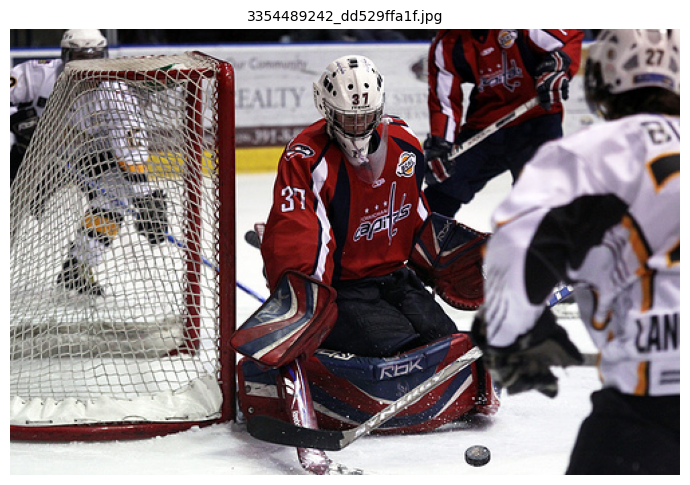

Didascalie (5 annotatori diversi):
  1. A goalie tries to block the puck in a hockey game .
  2. A hockey goalie stops the puck .
  3. People playing hockey .
  4. Several hockey players move toward the puck next to a goal .
  5. Two hockey teams compete .



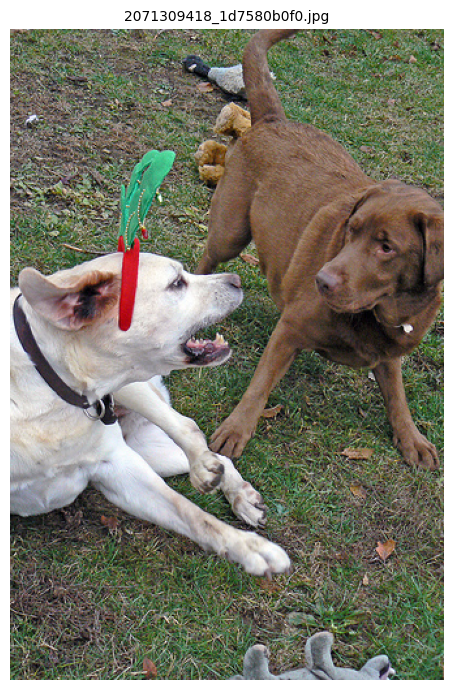

Didascalie (5 annotatori diversi):
  1. A white dog wearing a christmas reindeer headband plays with a brown dog in the grass among some stuffed animals .
  2. A white dog wearing reindeer ears is next to a brown dog .
  3. A white dog with fake antlers on its head and a brown dog play together outdoors .
  4. The white dog next to the brown dog is wearing a christmas headband .
  5. Two dogs , one wearing christmas antlers , tussle on the grass .



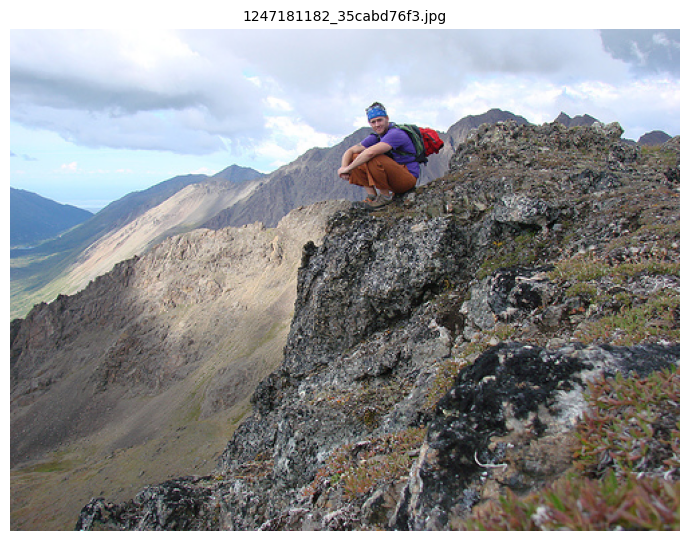

Didascalie (5 annotatori diversi):
  1. a man sits on a rock .
  2. A man sitting on a cliff in the mountains .
  3. A man wearing a blue shirt crouches on a rocky cliff .
  4. A person posing on a mountaintop .
  5. The man is sitting at the top of a rocky mountain .



In [3]:
import random

def show_image_with_captions(image_filename, df, images_dir):
    img_path = images_dir / image_filename
    img = Image.open(img_path)
    captions = df[df['image'] == image_filename]['caption'].tolist()
    
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(image_filename, fontsize=10)
    plt.tight_layout()
    plt.show()
    
    print("Didascalie (5 annotatori diversi):")
    for i, cap in enumerate(captions, 1):
        print(f"  {i}. {cap}")
    print()

random.seed(42)
sample_images = random.sample(df['image'].unique().tolist(), 3)
for img_name in sample_images:
    show_image_with_captions(img_name, df, IMAGES_DIR)

Statistiche lunghezza didascalie (in parole):
count    40455.000000
mean        11.782598
std          3.885152
min          1.000000
25%          9.000000
50%         11.000000
75%         14.000000
max         38.000000
Name: caption_length, dtype: float64

95° percentile: 19 parole
99° percentile: 23 parole
Massimo: 38 parole


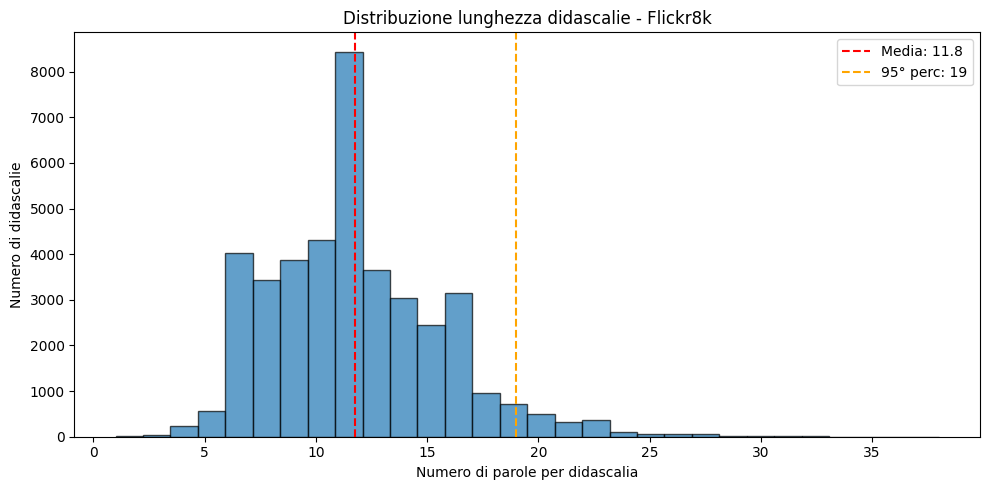

In [4]:
df['caption_length'] = df['caption'].str.split().str.len()

print("Statistiche lunghezza didascalie (in parole):")
print(df['caption_length'].describe())
print()
print(f"95° percentile: {df['caption_length'].quantile(0.95):.0f} parole")
print(f"99° percentile: {df['caption_length'].quantile(0.99):.0f} parole")
print(f"Massimo: {df['caption_length'].max()} parole")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['caption_length'], bins=30, edgecolor='black', alpha=0.7)
ax.set_xlabel('Numero di parole per didascalia')
ax.set_ylabel('Numero di didascalie')
ax.set_title('Distribuzione lunghezza didascalie - Flickr8k')
ax.axvline(df['caption_length'].mean(), color='red', linestyle='--',
           label=f"Media: {df['caption_length'].mean():.1f}")
ax.axvline(df['caption_length'].quantile(0.95), color='orange', linestyle='--',
           label=f"95° perc: {df['caption_length'].quantile(0.95):.0f}")
ax.legend()
plt.tight_layout()
plt.show()

In [5]:
from collections import Counter

all_words = []
for caption in df['caption']:
    words = caption.lower().split()
    all_words.extend(words)

word_counts = Counter(all_words)
print(f"Vocabolario totale (split semplice): {len(word_counts)} parole uniche")
print(f"Token totali: {len(all_words)}")
print()
print("Top 25 parole piu' frequenti:")
for word, count in word_counts.most_common(25):
    print(f"  {word:15s} {count:>6}")

Vocabolario totale (split semplice): 8918 parole uniche
Token totali: 476665

Top 25 parole piu' frequenti:
  a                62986
  .                36577
  in               18974
  the              18418
  on               10743
  is                9345
  and               8851
  dog               8136
  with              7765
  man               7265
  of                6713
  two               5638
  white             3940
  black             3832
  boy               3581
  are               3504
  woman             3402
  girl              3328
  ,                 3232
  to                3173
  wearing           3062
  at                2914
  people            2883
  water             2783
  red               2672


In [6]:
# Quante parole "rare" ci sono?
total_unique = len(word_counts)
threshold_levels = [1, 2, 3, 5, 10]

print("Coda lunga del vocabolario:")
print(f"{'Soglia min frequenza':<25} {'# parole':<12} {'% del vocabolario':<20}")
for t in threshold_levels:
    n = sum(1 for w, c in word_counts.items() if c < t + 1)
    pct = 100 * n / total_unique
    print(f"  apparse <= {t} volte{'':<6} {n:<12} {pct:.1f}%")

print()

# Coverage: quante delle occorrenze totali sono coperte dalle top-K parole?
sorted_counts = sorted(word_counts.values(), reverse=True)
total_tokens = sum(sorted_counts)

print("Coverage del vocabolario:")
print(f"{'Top-K parole':<15} {'% token coperti':<20}")
for k in [500, 1000, 2000, 3000, 5000, 8000]:
    if k <= len(sorted_counts):
        coverage = 100 * sum(sorted_counts[:k]) / total_tokens
        print(f"  Top {k:<10} {coverage:.2f}%")

Coda lunga del vocabolario:
Soglia min frequenza      # parole     % del vocabolario   
  apparse <= 1 volte       3681         41.3%
  apparse <= 2 volte       4815         54.0%
  apparse <= 3 volte       5477         61.4%
  apparse <= 5 volte       6266         70.3%
  apparse <= 10 volte       7063         79.2%

Coverage del vocabolario:
Top-K parole    % token coperti     
  Top 500        88.07%
  Top 1000       93.13%
  Top 2000       96.61%
  Top 3000       97.97%
  Top 5000       99.13%
  Top 8000       99.81%


## Decisioni progettuali sulla tokenizzazione

Dall'analisi sopra emerge che:

- Il vocabolario "naturale" del dataset è di ~9000 parole, ma con coda lunga estrema:
  il 41% appare 1 sola volta, il 79% appare ≤10 volte.
- Con sole 3000 parole si copre il 98% del testo, ma il restante 2% include
  nomi propri e termini specifici che diventerebbero `<unk>`.

**Scelta: tokenizer subword pre-addestrato (GPT-2 BPE).**

Motivazioni:
1. Elimina il problema delle parole fuori vocabolario (nessun `<unk>`)
2. Si integra naturalmente con il decoder GPT-2 pre-addestrato che useremo
3. Sfrutta conoscenza linguistica acquisita su miliardi di parole, ben oltre Flickr8k
4. Token a livello di sub-parola → migliore generalizzazione su parole rare composte

Limite del decoder: `max_length = 30` token (copre il 99° percentile delle didascalie
del dataset, considerando l'overhead della tokenizzazione subword e dei token speciali).

In [7]:
import numpy as np

# Lista di tutte le immagini uniche
all_images = sorted(df['image'].unique().tolist())
print(f"Totale immagini uniche: {len(all_images)}")

# Shuffle deterministico (seed fisso = riproducibilita')
rng = np.random.default_rng(seed=42)
shuffled = all_images.copy()
rng.shuffle(shuffled)

# Split per immagine (NON per riga del CSV: evitiamo data leakage)
n_train = 6000
n_val = 1000
# n_test = il resto (1091)

train_images = set(shuffled[:n_train])
val_images = set(shuffled[n_train:n_train + n_val])
test_images = set(shuffled[n_train + n_val:])

print(f"Train: {len(train_images)} immagini")
print(f"Val:   {len(val_images)} immagini")
print(f"Test:  {len(test_images)} immagini")

# Verifica: nessuna sovrapposizione (sanity check)
assert len(train_images & val_images) == 0
assert len(train_images & test_images) == 0
assert len(val_images & test_images) == 0
print("\n✓ Nessuna sovrapposizione tra split (no data leakage)")

# Aggiungi una colonna 'split' al DataFrame
def get_split(img_name):
    if img_name in train_images:
        return 'train'
    elif img_name in val_images:
        return 'val'
    else:
        return 'test'

df['split'] = df['image'].apply(get_split)
print()
print("Distribuzione delle didascalie per split:")
print(df['split'].value_counts())

Totale immagini uniche: 8091
Train: 6000 immagini
Val:   1000 immagini
Test:  1091 immagini

✓ Nessuna sovrapposizione tra split (no data leakage)

Distribuzione delle didascalie per split:
split
train    30000
test      5455
val       5000
Name: count, dtype: int64


In [8]:
SPLIT_FILE = DATA_DIR / "captions_with_split.csv"
df.to_csv(SPLIT_FILE, index=False)
print(f"Split salvato in: {SPLIT_FILE}")
print(f"Dimensione file: {SPLIT_FILE.stat().st_size / 1024:.1f} KB")

Split salvato in: c:\dev\image-captioning\data\flickr8k\captions_with_split.csv
Dimensione file: 3609.6 KB


## Test del tokenizer GPT-2

Verifichiamo concretamente come il tokenizer subword di GPT-2 si comporta
sulle didascalie di Flickr8k. Misuriamo la vera lunghezza in token (non in parole)
per confermare la scelta di `max_length = 30`.

In [9]:
from transformers import GPT2Tokenizer

# Carica il tokenizer pre-addestrato. Prima volta: scarica ~1 MB da HuggingFace
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")

# GPT-2 di default non ha un padding token: usiamo eos_token come pad
tokenizer.pad_token = tokenizer.eos_token

print(f"Vocabolario GPT-2: {tokenizer.vocab_size} token")
print(f"Token speciali: BOS={tokenizer.bos_token!r}, EOS={tokenizer.eos_token!r}")
print()

# Esempio 1: didascalia normale
example1 = "A little girl climbing into a wooden playhouse ."
tokens1 = tokenizer.tokenize(example1)
ids1 = tokenizer.encode(example1)
print(f"Esempio 1: {example1!r}")
print(f"  Token ({len(tokens1)}): {tokens1}")
print(f"  IDs   ({len(ids1)}): {ids1}")
print()

# Esempio 2: con parola "rara" composta
example2 = "A skateboarder performs a kickflip on a graffitied ramp ."
tokens2 = tokenizer.tokenize(example2)
print(f"Esempio 2: {example2!r}")
print(f"  Token ({len(tokens2)}): {tokens2}")
print()

# Esempio 3: con nome proprio
example3 = "A Yorkshire terrier wearing a Chicago Bulls jersey ."
tokens3 = tokenizer.tokenize(example3)
print(f"Esempio 3: {example3!r}")
print(f"  Token ({len(tokens3)}): {tokens3}")

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Vocabolario GPT-2: 50257 token
Token speciali: BOS='<|endoftext|>', EOS='<|endoftext|>'

Esempio 1: 'A little girl climbing into a wooden playhouse .'
  Token (10): ['A', 'Ġlittle', 'Ġgirl', 'Ġclimbing', 'Ġinto', 'Ġa', 'Ġwooden', 'Ġplay', 'house', 'Ġ.']
  IDs   (10): [32, 1310, 2576, 14281, 656, 257, 13510, 711, 4803, 764]

Esempio 2: 'A skateboarder performs a kickflip on a graffitied ramp .'
  Token (17): ['A', 'Ġskate', 'board', 'er', 'Ġperforms', 'Ġa', 'Ġkick', 'fl', 'ip', 'Ġon', 'Ġa', 'Ġgra', 'ff', 'it', 'ied', 'Ġramp', 'Ġ.']

Esempio 3: 'A Yorkshire terrier wearing a Chicago Bulls jersey .'
  Token (10): ['A', 'ĠYorkshire', 'Ġter', 'rier', 'Ġwearing', 'Ġa', 'ĠChicago', 'ĠBulls', 'Ġjersey', 'Ġ.']


In [10]:
from tqdm import tqdm

# Tokenizziamo tutte le didascalie con barra di progresso
print("Tokenizzazione di tutte le didascalie...")
token_lengths = []
for caption in tqdm(df['caption'].tolist()):
    # Aggiungiamo BOS/EOS come faremo in training
    text = tokenizer.bos_token + " " + caption + " " + tokenizer.eos_token
    n_tokens = len(tokenizer.encode(text))
    token_lengths.append(n_tokens)

df['n_tokens'] = token_lengths

print()
print("Statistiche lunghezza didascalie (in token GPT-2, BOS+caption+EOS):")
print(df['n_tokens'].describe())
print()
print(f"95° percentile: {df['n_tokens'].quantile(0.95):.0f} token")
print(f"99° percentile: {df['n_tokens'].quantile(0.99):.0f} token")
print(f"Massimo:        {df['n_tokens'].max()} token")
print()

# Quante didascalie supereranno max_length=30 e verranno troncate?
for ml in [25, 30, 32, 40]:
    n_over = (df['n_tokens'] > ml).sum()
    pct = 100 * n_over / len(df)
    print(f"  max_length = {ml}: {n_over} didascalie troncate ({pct:.2f}%)")

Tokenizzazione di tutte le didascalie...


100%|██████████| 40455/40455 [00:01<00:00, 31804.00it/s]


Statistiche lunghezza didascalie (in token GPT-2, BOS+caption+EOS):
count    40455.000000
mean        15.353108
std          4.055161
min          4.000000
25%         12.000000
50%         15.000000
75%         18.000000
max         44.000000
Name: n_tokens, dtype: float64

95° percentile: 23 token
99° percentile: 27 token
Massimo:        44 token

  max_length = 25: 728 didascalie troncate (1.80%)
  max_length = 30: 120 didascalie troncate (0.30%)
  max_length = 32: 55 didascalie troncate (0.14%)
  max_length = 40: 3 didascalie troncate (0.01%)


## Riassunto delle decisioni progettuali

Dalla fase esplorativa emergono le seguenti scelte:

**Dataset**
- Flickr8k: 8091 immagini × 5 didascalie = 40455 esempi
- Split per immagine (no leakage): 6000 train / 1000 val / 1091 test
- Split deterministico (seed=42), salvato in `data/flickr8k/captions_with_split.csv`

**Tokenizzazione**
- Tokenizer: GPT-2 BPE pre-addestrato (50257 token)
- Eliminazione del problema OOV: nessun `<unk>` necessario
- Token speciale: `<|endoftext|>` per BOS e EOS

**Lunghezza sequenze**
- `max_length = 30` token (BOS + didascalia + EOS)
- Copre il 99.7% del dataset senza troncatura
- Trade-off ottimale tra copertura e costo computazionale del decoder

**Architettura prevista (prossimo notebook)**
- Encoder: ViT pre-addestrato (Vision Transformer)
- Decoder: GPT-2 small pre-addestrato
- Cross-attention da decoder a feature ViT
- Loss: cross-entropy con teacher forcing

In [ ]:
SPLIT_FILE = DATA_DIR / "captions_with_split.csv"
df.to_csv(SPLIT_FILE, index=False)
print(f"File aggiornato salvato in: {SPLIT_FILE}")
print(f"Colonne disponibili: {list(df.columns)}")
print(f"Dimensione: {SPLIT_FILE.stat().st_size / 1024:.1f} KB")

File aggiornato salvato in: c:\dev\image-captioning\data\flickr8k\captions_with_split.csv
Colonne disponibili: ['image', 'caption', 'caption_length', 'split', 'n_tokens']
Dimensione: 3726.5 KB
